In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1 Monthly Revenue

In [2]:
df_mon_rev = pd.read_csv(r'C:\Users\MSI\Desktop\Data Project\Olist\02_SQL_Analysis_and_Insights\query_01_monthly_revenue.csv')
df_mon_rev.head()

,month_year,total_revenue,total_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653


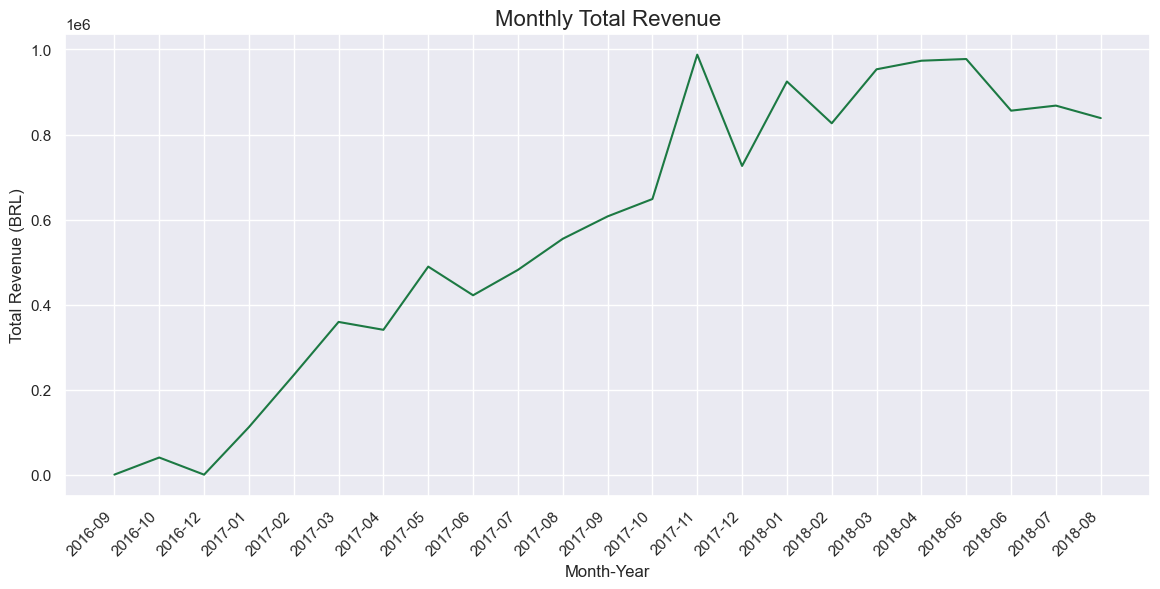

In [3]:
sns.set_theme(style = 'darkgrid')
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_mon_rev, x = 'month_year', y = 'total_revenue', color = '#1c7943')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue (BRL)')
plt.title('Monthly Total Revenue', fontsize = 16)
plt.xticks(rotation = 45, ha = 'right')
plt.show()

**Insights**
1. Total revenue exhibits a consistent upward trend throughout the analyzed period, showing strong business expansion.
2. The highest revenue was recorded in November 2017, reaching nearly 1,000,000 BRL. This significant spike is likely driven by the Black Friday shopping season.

## 2 Product Categories

In [4]:
df_top_cate = pd.read_csv(r'C:\Users\MSI\Desktop\Data Project\Olist\02_SQL_Analysis_and_Insights\query_02_top10_categories.csv')
df_last_cate = pd.read_csv(r'C:\Users\MSI\Desktop\Data Project\Olist\02_SQL_Analysis_and_Insights\query_03_last10_categories.csv')
df_top_cate.head()

,product_category,total_revenue,total_sold
0,health_beauty,1233131.72,9465
1,watches_gifts,1166176.98,5859
2,bed_bath_table,1023434.76,10953
3,sports_leisure,954852.55,8431
4,computers_accessories,888724.61,7644


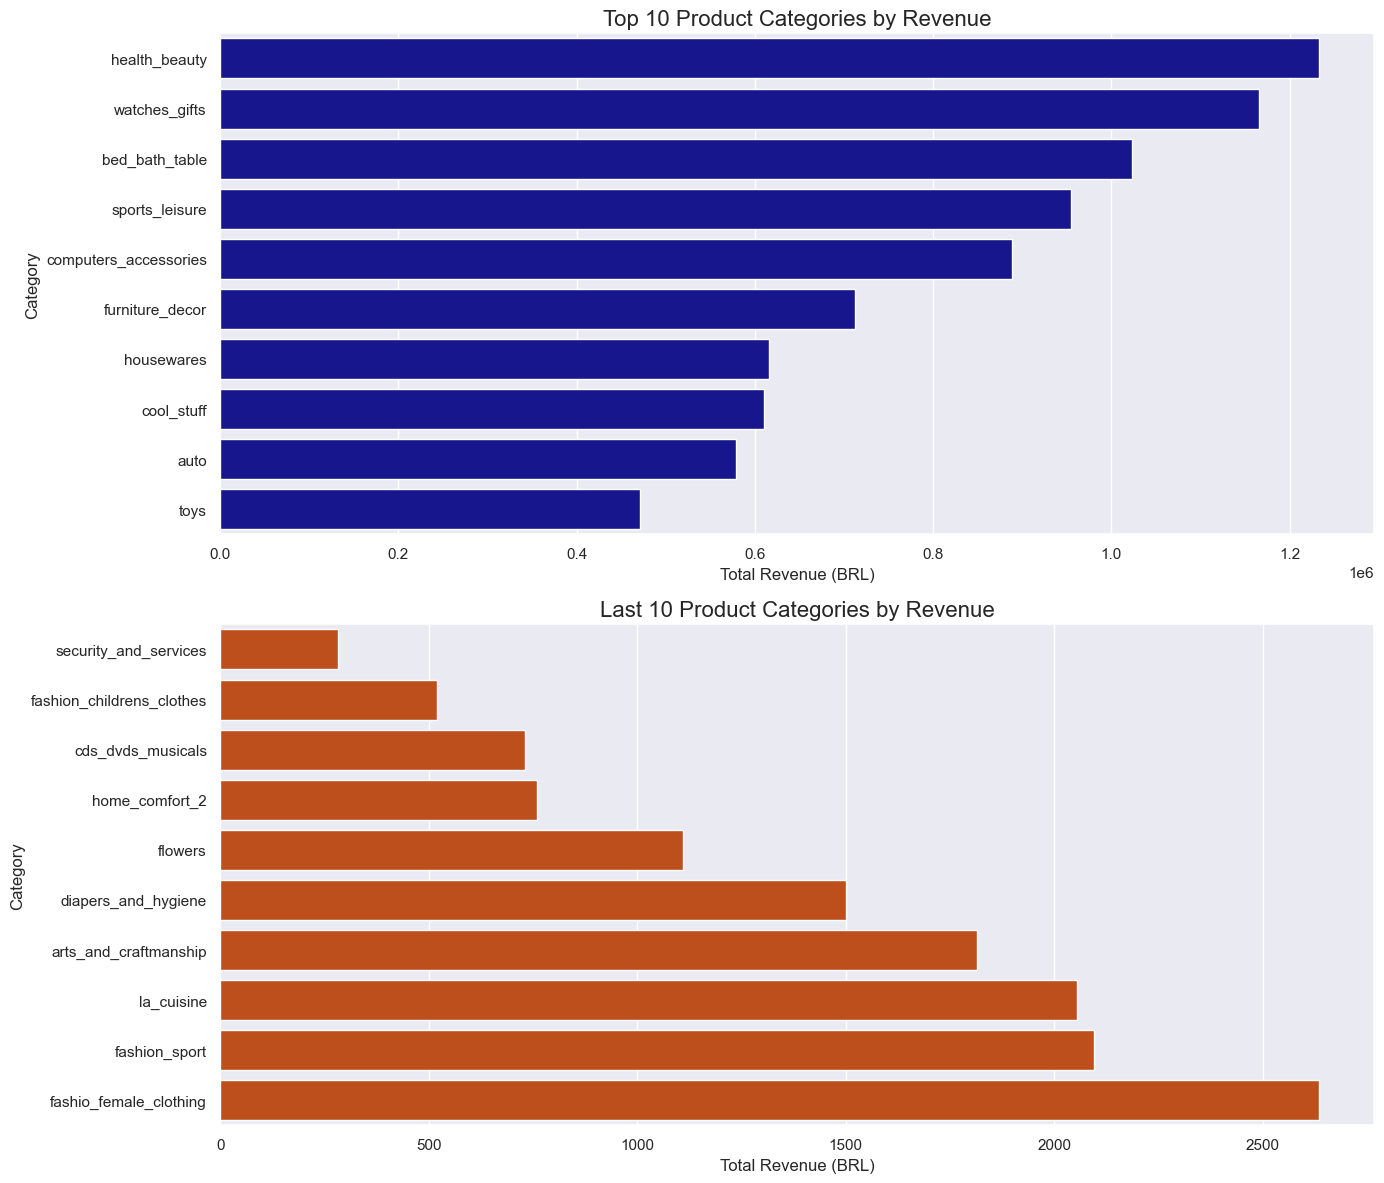

In [5]:
fig, axes = plt.subplots(2, 1, figsize = (14, 12))

sns.barplot(data = df_top_cate, x = 'total_revenue', y = 'product_category', ax = axes[0], color = "#0502a1")
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].set_ylabel('Category')
axes[0].set_title('Top 10 Product Categories by Revenue', fontsize = 16)

sns.barplot(data = df_last_cate, x = 'total_revenue', y = 'product_category', ax = axes[1], color = "#d64502")
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('Category')
axes[1].set_title('Last 10 Product Categories by Revenue', fontsize = 16)

plt.tight_layout()
plt.show()

**Insights**
1. Olist's main revenue comes from the health & beauty and watches & gifts categories.
2. Low-performing categories such as Security & Services and fashion children clothes represent untapped niche markets.
3. A massive contrast in sales confirms the 80/20 Pareto Principle within the Olist ecosystem.

## 3 Shipping Performance

In [6]:
df_ship = pd.read_csv(r'C:\Users\MSI\Desktop\Data Project\Olist\02_SQL_Analysis_and_Insights\query_04_slowest_state.csv')
df_ship.head()

,customer_state,avg_day_to_customers
0,RR,29.387546
1,AP,27.185068
2,AM,26.425991
3,AL,24.543855
4,PA,23.772917


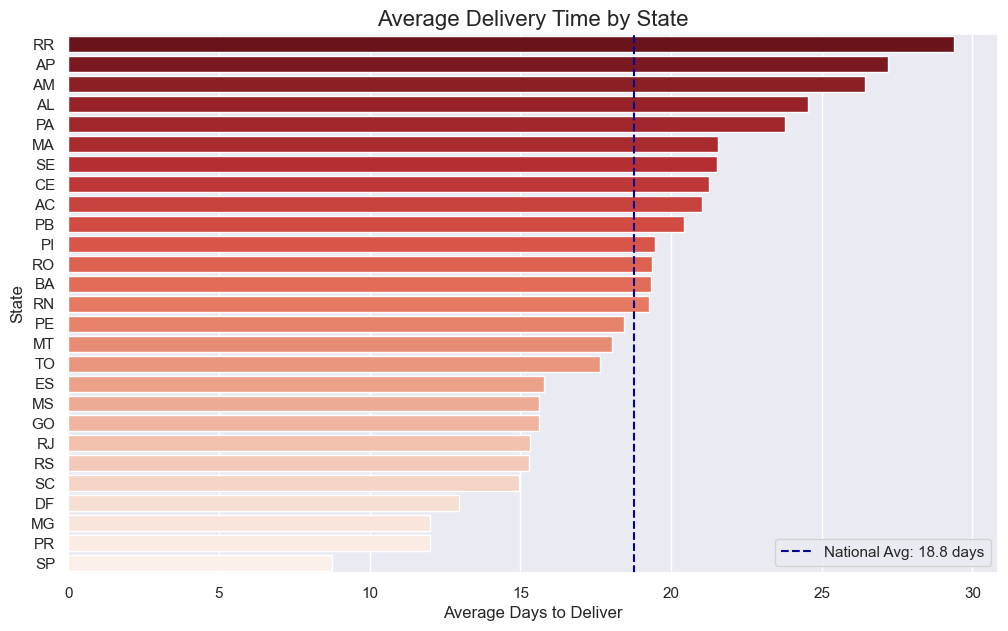

In [7]:
plt.figure(figsize = (12, 7))
sns.barplot(data = df_ship, x = 'avg_day_to_customers', y = 'customer_state', hue = 'customer_state', palette = 'Reds_r')

avg_national = df_ship['avg_day_to_customers'].mean()
plt.axvline(avg_national, color = "#05029c", linestyle = '--', label = f'National Avg: {avg_national:.1f} days')

plt.xlabel('Average Days to Deliver')
plt.ylabel('State')
plt.title('Average Delivery Time by State', fontsize = 16)
plt.legend()
plt.show()

**Insights**
1. States like RR (Roraima) and AP (Amapá) show significantly higher delivery times compared to the national average, likely due to geographical challenges.
2. The core states (e.g., SP, PR) maintain the fastest delivery speeds, benefiting from better infrastructure and proximity to distribution centers.

## 4 Payment Methods

In [8]:
df_pay = pd.read_csv(r'C:\Users\MSI\Desktop\Data Project\Olist\02_SQL_Analysis_and_Insights\query_05_payment_analysis.csv')
df_pay.head()

,payment_type,total_payment_value,avg_payment_value,avg_installments
0,credit_card,12542084.19,163.319021,3.507155
1,boleto,2869361.27,145.034435,1.000000
2,voucher,379436.87,65.703354,1.000000
3,debit_card,217989.79,142.570170,1.000000
4,not_defined,0.00,0.000000,1.000000


In [9]:
df_pay = df_pay.drop([4], axis = 0)

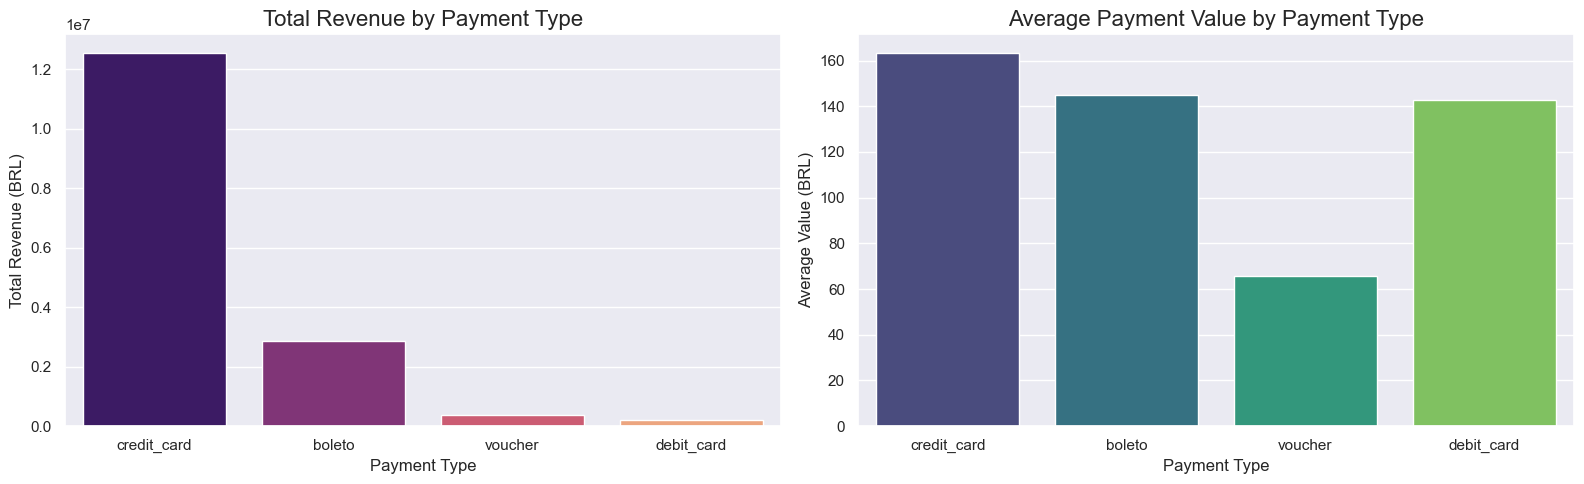

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (16, 5))

sns.barplot(data = df_pay, x = 'payment_type', y = 'total_payment_value', ax = axes[0], hue = 'payment_type', palette = 'magma')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Total Revenue (BRL)')
axes[0].set_title('Total Revenue by Payment Type', fontsize = 16)

sns.barplot(data = df_pay, x = 'payment_type', y = 'avg_payment_value', ax = axes[1], hue = 'payment_type', palette = 'viridis')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Average Value (BRL)')
axes[1].set_title('Average Payment Value by Payment Type', fontsize = 16)

plt.tight_layout()
plt.show()

**Insights**
1. Credit Card is the primary driver of revenue, significantly outperforming other payment methods in total volume.
2. Credit Card also has the highest Average Payment Value, which is directly linked to the use of installment plans (averaging over 3-5 months).
3. The popularity of Boleto shows that a large portion of customers still prefers or relies on cash-based vouchers for online shopping.